# Hybrid Dual-Frequency Ticker-Specific HMM

Quy trình kết hợp đánh giá Vĩ mô (Monthly) và Thị trường chung (Daily) để định vị pha biến động, sau đó ép cấu trúc thị trường chung lên từng mã cổ phiếu (Ticker-Specific) và dùng Meta-Classifier dự đoán lợi suất ngày tới.

In [10]:
def get_hmm_filtered_inference(model, Z):
    import numpy as np
    N = len(Z)
    K = model.n_components
    filtered_probs = np.zeros((N, K))
    filtered_regimes = np.zeros(N, dtype=int)
    for t in range(1, N + 1):
        Z_slice = Z[:t]
        try:
            probs_slice = model.predict_proba(Z_slice)
            filtered_probs[t-1] = probs_slice[-1]
            regimes_slice = model.predict(Z_slice)
            filtered_regimes[t-1] = regimes_slice[-1]
        except Exception as e:
            filtered_probs[t-1] = np.ones(K) / K
            filtered_regimes[t-1] = 0
    return filtered_regimes, filtered_probs


import os
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew, kurtosis, norm
from sklearn.feature_selection import mutual_info_regression
from hmmlearn.hmm import GMMHMM, GaussianHMM
import lightgbm as lgb
import shap
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path('../output/hmm_v3_op1_extended')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Thư mục đầu ra được thiết lập tại: {OUTPUT_DIR.resolve()}")

Thư mục đầu ra được thiết lập tại: C:\Users\ADMIN\Desktop\Kaggle\output\hmm_v3_op1_extended


## 1. Tải Dữ Liệu & Tạo Chỉ Báo Thị Trường Đại Diện (VN-Index Proxy)

In [11]:
print("Đang tải dữ liệu hmm_data.csv và m1_vn46.csv...")
df_daily_base = pd.read_csv('../output/hmm_data.csv')
df_daily_base['time'] = pd.to_datetime(df_daily_base['time'])

df_m1 = pd.read_csv('../data/processed/m1_vn46.csv')
df_m1['time'] = pd.to_datetime(df_m1['time']).dt.normalize()

# Tạo Market Proxy từ rổ VN46
market_ret = df_m1.groupby('time')['log_return'].mean().reset_index()
market_ret.columns = ['time', 'vnindex_log_ret']
market_close = df_m1.groupby('time')['close'].mean().reset_index()
market_close.columns = ['time', 'vnindex_close']

df_market = df_daily_base.merge(market_ret, on='time', how='left')
df_market = df_market.merge(market_close, on='time', how='left')
df_market = df_market.dropna(subset=['vnindex_log_ret', 'vnindex_close']).reset_index(drop=True)
df_market['vnindex_vol20'] = df_market['vnindex_log_ret'].rolling(20).std() * np.sqrt(252)

try:
    df_fnb = pd.read_csv('../data/processed/m4_foreign_net_buy_sell.csv')
    df_fnb['time'] = pd.to_datetime(df_fnb['time'])
    df_market = df_market.merge(df_fnb[['time', 'fnb_ratio']], on='time', how='left')
except:
    pass

try:
    df_fx = pd.read_csv('../data/processed/e1_usdvnd.csv')
    df_fx['time'] = pd.to_datetime(df_fx['time'])
    df_market = df_market.merge(df_fx[['time', 'fx_log_ret']], on='time', how='left')
except:
    pass

df_market = df_market.dropna().reset_index(drop=True)
print(f"Kích thước bảng dữ liệu Market gốc: {df_market.shape}")

Đang tải dữ liệu hmm_data.csv và m1_vn46.csv...
Kích thước bảng dữ liệu Market gốc: (2382, 13)


## 2. Bộ Lọc Kiểm Định Kỹ Thuật (Stationarity & Kurtosis)

Mục đích của bước này là đánh giá tính chất toán học của các đặc trưng để chọn lọc đầu vào ổn định cho HMM:
1. **Kiểm định tính dừng (Stationarity):** Sử dụng cả ADF (yêu cầu bác bỏ giả thuyết không, $p < 0.05$) và KPSS (yêu cầu chấp nhận giả thuyết không, $p \ge 0.05$) để kiểm tra chuỗi dừng thực tế ở dạng $I(0)$. Chuỗi dừng đảm bảo các thuộc tính thống kê không thay đổi theo thời gian, tránh lỗi ước lượng suy biến.
2. **Hệ số nhọn (Excess Kurtosis):** Kiểm tra xem phân phối của biến có đuôi quá dày hay không ($|kurt| < 10$). Phân phối lệch chuẩn quá mức sẽ vi phạm giả định phân phối Gauss ẩn của HMM.

### Bảng giải thích các chỉ số kiểm định:

| Chỉ số (Metric) | Ý nghĩa (Meaning) | Ngưỡng chấp nhận (Threshold) | Tác dụng trong HMM (Purpose in HMM) |
| :--- | :--- | :--- | :--- |
| **ADF (p-value)** | Kiểm định giả thuyết nghiệm đơn vị (Unit Root). Giả thuyết $H_0$: Chuỗi không dừng. | $p < 0.05$ (Bác bỏ $H_0$, chuỗi dừng) | HMM yêu cầu các đặc trưng đầu vào có tính phân phối ổn định qua thời gian để tránh sai số ước lượng. |
| **KPSS (p-value)** | Kiểm định tính dừng xung quanh xu thế. Giả thuyết $H_0$: Chuỗi dừng. | $p \ge 0.05$ (Không bác bỏ $H_0$, chuỗi dừng) | Bổ trợ cho ADF để xác nhận chắc chắn chuỗi dừng (tránh lỗi ngụy tạo từ ADF). |
| **Kurtosis (Hệ số nhọn)** | Đo lường mức độ tập trung của phân phối quanh giá trị trung bình và độ dày của đuôi. | $\vert \text{Kurt} \vert < 10$ | Tránh hiện tượng đuôi quá béo (fat-tails) gây nhiễu cho ước lượng GMM trong HMM. |
| **Skewness (Hệ số lệch)** | Đo lường tính bất đối xứng của phân phối dữ liệu quanh giá trị trung bình. | Ghi nhận mô tả | Đánh giá xu hướng lệch của biến trước khi nạp vào phân phối chuẩn hỗn hợp. |

In [12]:
def check_stationarity(s):
    s = s.dropna()
    if len(s) < 30: return False, np.nan, np.nan, np.nan, np.nan
    p_adf = adfuller(s, autolag='AIC')[1]
    p_kpss = kpss(s, regression='c', nlags='auto')[1] 
    kurt = kurtosis(s)
    skw = skew(s)
    is_stat = (p_adf < 0.05) and (p_kpss >= 0.05) and (abs(kurt) < 10)
    return is_stat, p_adf, p_kpss, kurt, skw

daily_pool = [c for c in df_market.columns if c not in ['time', 'vnindex_log_ret', 'vnindex_close', 'vnindex_vol20']]
stat_results = []
for c in daily_pool:
    is_stat, p_a, p_k, kurt, skw = check_stationarity(df_market[c])
    stat_results.append({'feature': c, 'is_stationary': is_stat, 'p_adf': p_a, 'p_kpss': p_k, 'kurtosis': kurt, 'skewness': skw})
stat_df = pd.DataFrame(stat_results)
display(stat_df)

selected_raw_features = stat_df[stat_df['is_stationary']]['feature'].tolist()
if not selected_raw_features:
    selected_raw_features = daily_pool # Fallback

print(f'\n[KEEP] Các đặc trưng ĐƯỢC GIỮ LẠI ({len(selected_raw_features)} biến): {selected_raw_features}')
dropped = [c for c in daily_pool if c not in selected_raw_features]
print(f'[DROP] Các đặc trưng BỊ LOẠI BỎ ({len(dropped)} biến): {dropped}')



,feature,is_stationary,p_adf,p_kpss,kurtosis,skewness
0,amihud_diff_normalized,False,1.651416e-20,0.10000,13.695413,-1.278046
1,ret_disp,False,8.502861e-04,0.01000,-0.314443,0.357147
2,rolling_vol_5,True,8.141576e-06,0.07052,6.881312,2.210501
3,volume_ratio,True,1.977164e-21,0.10000,0.465722,0.678169
4,credit_growth_mom,True,1.209938e-16,0.10000,-0.299473,0.304310
5,cpi_mom,True,1.612280e-10,0.10000,4.165647,0.906156
6,pmi_vn,False,9.079260e-02,0.10000,-0.912275,-0.045626
7,fnb_ratio,True,1.216916e-05,0.10000,-0.086172,0.106597
8,fx_log_ret,False,2.008699e-18,0.10000,10.397364,0.105826



[KEEP] Các đặc trưng ĐƯỢC GIỮ LẠI (5 biến): ['rolling_vol_5', 'volume_ratio', 'credit_growth_mom', 'cpi_mom', 'fnb_ratio']
[DROP] Các đặc trưng BỊ LOẠI BỎ (4 biến): ['amihud_diff_normalized', 'ret_disp', 'pmi_vn', 'fx_log_ret']


## 3. Thiết Lập Tập Dữ Liệu Train/OOS & Hàm Hỗ Trợ HMM sử dụng NQT + Rank

In [13]:
HMM_TRAIN_END = pd.Timestamp('2019-12-31')

def make_Z(df, features, window=252):
    fd = df[['time'] + features].dropna().reset_index(drop=True)
    nqt_df = pd.DataFrame(index=fd.index)
    for col in features:
        rolling_rank = fd[col].rolling(window=window, min_periods=1).rank()
        rolling_count = fd[col].rolling(window=window, min_periods=1).count()
        pct = (rolling_rank - 0.5) / rolling_count
        nqt_values = norm.ppf(pct)
        nqt_df[col] = np.clip(nqt_values, -3.0, 3.0)
    Z_all = nqt_df.values
    train_mask = fd['time'] <= HMM_TRAIN_END
    Z_tr = Z_all[train_mask]
    return fd, Z_tr, Z_all

fd_market, Z_tr_market, Z_all_market = make_Z(df_market, selected_raw_features)
df_market_Z = pd.DataFrame(Z_all_market, columns=[c + '_Z' for c in selected_raw_features])
fd_market = fd_market.merge(df_market[['time', 'vnindex_log_ret', 'vnindex_close', 'vnindex_vol20']], on='time', how='left')
df_market = pd.concat([fd_market, df_market_Z], axis=1)

## 4. Điểm Thông Tin Tương Hỗ (Mutual Information - MI) & Lựa Chọn Đặc Trưng Tham Lam & Kiểm Soát VIF

Điểm MI đo lường mức độ phụ thuộc thông tin (kể cả phi tuyến) giữa đặc trưng đầu vào và trị tuyệt đối lợi suất thị trường `|vnindex_log_ret|` (đại diện cho trạng thái biến động). Điểm số MI cao chỉ ra biến đó có khả năng giải thích cao cho sự thay đổi biến động.

### Bảng giải thích các chỉ số đo lường lượng tin:

| Chỉ số (Metric) | Ý nghĩa (Meaning) | Ngưỡng chấp nhận (Threshold) | Tác dụng trong HMM (Purpose in HMM) |
| :--- | :--- | :--- | :--- |
| **Mutual Information (MI)** | Đo lường lượng thông tin chung thu được về biến mục tiêu thông qua đặc trưng đầu vào (kể cả quan hệ phi tuyến). | Càng cao càng tốt ($\text{MI} > 0.01$ khuyên dùng) | Xác định đặc trưng nào chứa nhiều thông tin giải thích nhất cho trạng thái biến động của thị trường. |

Hàm lọc biến đảm bảo tính đa dạng và hạn chế đa cộng tuyến tuyến tính sử dụng điểm số MI kết hợp hệ số phóng đại phương sai VIF.

### Bảng giải thích chỉ số kiểm soát đa cộng tuyến và đa dạng:

| Chỉ số (Metric) | Ý nghĩa (Meaning) | Ngưỡng chấp nhận (Threshold) | Tác dụng trong HMM (Purpose in HMM) |
| :--- | :--- | :--- | :--- |
| **Variance Inflation Factor (VIF)** | Đo lường mức độ ảnh hưởng của hiện tượng đa cộng tuyến (multicollinearity) giữa một đặc trưng với các đặc trưng khác. | $\text{VIF} < 5.0$ (Tốt); $\text{VIF} \ge 10.0$ (Đa cộng tuyến nghiêm trọng) | Ngăn ngừa ma trận hiệp phương sai của HMM bị suy biến (null eigenvalue) khi huấn luyện mô hình Gauss hỗn hợp. |
| **Block Diversity** | Đảm bảo tính đa dạng thông tin bằng cách lấy ít nhất một biến đại diện từ mỗi khâu (`Market`, `Economy`, `Credit`). | Bắt buộc chọn từ các nhóm khác nhau | Giúp HMM quan sát thị trường từ nhiều khía cạnh bổ trợ thay vì chỉ tập trung vào một nguồn tin. |

In [14]:
# Tạo Y_proxy rule-based cho Market
# Normalize duplicated merge columns if present
for std_col in ['vnindex_log_ret', 'vnindex_vol20']:
    if std_col not in df_market.columns:
        alt = next((c for c in [f'{std_col}_y', f'{std_col}_x'] if c in df_market.columns), None)
        if alt is None:
            raise KeyError(f"{std_col} column not found in df_market")
        df_market = df_market.rename(columns={alt: std_col})

df_market = df_market.loc[:, ~df_market.columns.duplicated()]
vol_median = df_market['vnindex_vol20'].median()
def label_proxy(row):
    ret = row['vnindex_log_ret']
    vol = row['vnindex_vol20']
    if ret > 0 and vol < vol_median: return 0 # Bull / Low Vol
    elif ret < 0 and vol > vol_median: return 1 # Bear / High Vol
    else: return 2 # Sideways

df_market['Y_proxy'] = df_market.apply(label_proxy, axis=1)

Z_features = [c + '_Z' for c in selected_raw_features]
X_train = df_market[Z_features].dropna()
y_train = df_market.loc[X_train.index, 'Y_proxy']

# Tính SHAP
clf = lgb.LGBMClassifier(n_estimators=50, random_state=RANDOM_STATE, verbose=-1)
clf.fit(X_train, y_train)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_train)
if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    vals = shap_values.values if hasattr(shap_values, 'values') else np.array(shap_values)
    if len(vals.shape) == 3:
        if vals.shape[1] == len(Z_features):
            mean_shap = np.abs(vals).mean(axis=0).mean(axis=1)
        else:
            mean_shap = np.abs(vals).mean(axis=0).mean(axis=0)
    else:
        mean_shap = np.abs(vals).mean(axis=0)
shap_df = pd.DataFrame({'feature': Z_features, 'shap_importance': mean_shap})

# Tính MI với |vnindex_log_ret|
target_mi = np.abs(df_market.loc[X_train.index, 'vnindex_log_ret'])
mi_scores = mutual_info_regression(X_train, target_mi, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': Z_features, 'mi_score': mi_scores})

# Gộp điểm & Lọc VIF tham lam
feature_scores = shap_df.merge(mi_df, on='feature')
feature_scores['total_score'] = feature_scores['shap_importance'] * feature_scores['mi_score']
feature_scores = feature_scores.sort_values('total_score', ascending=False)

def filter_vif_greedy(df, features, threshold=5.0):
    selected = []
    for f in features:
        trial = selected + [f]
        X_sub = df[trial].values
        X_sub = np.column_stack([np.ones(len(X_sub)), X_sub])
        vif = variance_inflation_factor(X_sub, len(trial))
        if vif < threshold:
            selected.append(f)
    return selected

final_features = filter_vif_greedy(X_train, feature_scores['feature'].tolist())
print("Top features (SHAP+MI) qua bộ lọc VIF:")
macro_pool = [c for c in ['cpi_mom_Z', 'credit_growth_mom_Z', 'fnb_ratio_Z', 'pmi_vn_Z', 'fx_log_ret_Z'] if c in X_train.columns]
final_features = set(final_features).union(set(macro_pool))
macro_features = [f for f in final_features if f in macro_pool]
market_features = [f for f in final_features if f not in macro_pool]
print('Macro Features:', macro_features)
print('Market Features:', market_features)
display(feature_scores.head(10))


Top features (SHAP+MI) qua bộ lọc VIF:
Macro Features: ['credit_growth_mom_Z', 'fnb_ratio_Z', 'cpi_mom_Z']
Market Features: ['rolling_vol_5_Z', 'volume_ratio_Z']


,feature,shap_importance,mi_score,total_score
1,volume_ratio_Z,0.143845,0.040112,0.005770
3,cpi_mom_Z,0.283990,0.018636,0.005292
4,fnb_ratio_Z,0.083584,0.021467,0.001794
2,credit_growth_mom_Z,0.242137,0.003035,0.000735
0,rolling_vol_5_Z,0.230156,0.001721,0.000396


## 5. Chạy Grid Search Tìm Cấu Hình HMM Tốt Nhất (Kiến Trúc Tách Lớp)

Hệ thống giờ đây được đánh giá theo 2 tầng:
1. **Tầng Vĩ Mô (Macro HMM):** Chạy trên khung thời gian Tháng (Monthly) sử dụng các biến Vĩ mô để xác định bối cảnh tổng thể. Dữ liệu được tịnh tiến (shift 1 tháng) để xử lý hoàn toàn vấn đề Look-ahead Bias do độ trễ công bố (Publication Lag).
2. **Tầng Thị Trường (Market HMM):** Chạy trên khung thời gian Ngày (Daily). Hấp thụ xác suất Vĩ Mô (`Macro_Prob`) kết hợp cùng các biến thị trường chung để xác định trạng thái rủi ro hàng ngày một cách toàn diện.

### Bảng giải thích các chỉ số đánh giá Grid Search HMM:

| Chỉ số (Metric) | Ý nghĩa (Meaning) | Ngưỡng chọn/Ràng buộc (Constraint) | Tác dụng trong tối ưu hóa HMM (Purpose in HMM) |
| :--- | :--- | :--- | :--- |
| **D** | Số lượng chiều (dimensions) của dữ liệu. | Tối ưu theo mô hình | Quyết định xem mỗi bước được quyết định bởi bao nhiêu biến số |
| **ll_in** | Log-Likelihood trong mẫu (In-sample). Đo lường độ khớp của mô hình với tập Train. | Càng cao càng tốt | Đánh giá khả năng giải thích dữ liệu huấn luyện của mô hình. |
| **ll_oos** | Log-Likelihood ngoài mẫu (Out-of-sample). Đo lường độ khớp trên tập kiểm thử chưa thấy ứng với seed tốt nhất. | Càng cao càng tốt | Đánh giá khả năng tổng quát hóa của mô hình tốt nhất chọn được. |
| **bic** | Chỉ số thông tin Bayesian (Bayesian Information Criterion). Phạt mô hình có quá nhiều tham số. | Càng thấp càng tốt | Lựa chọn số lượng đặc trưng và số trạng thái ẩn tối ưu nhất, ngăn chặn quá khớp (Overfitting). |
| **min_dur** | Thời gian lưu trú tối thiểu ở một trạng thái (Minimum State Duration). | $\ge 2$ phiên | Đảm bảo các trạng thái ẩn có tính bền vững nhất định, tránh chattering. |
| **min_share / max_share** | Tỷ lệ số phiên tối thiểu/tối đa thuộc một trạng thái trong tập Train. | $\text{min\_share} \ge 0.05$, $\text{max\_share} \le 0.85$ | Đảm bảo sự phân bổ cân bằng giữa các trạng thái ẩn. |

$$Composite = 0.3 \cdot Rank_{bic} + 0.5 \cdot Rank_{oos} + 0.2 \cdot Rank_{min\_dur}$$



In [15]:
import numpy as np
import pandas as pd
from hmmlearn.hmm import GMMHMM
import warnings

def n_params(K, D, M=2):
    return (K - 1) + K * (K - 1) + K * (M - 1) + K * M * D + K * M * D * (D + 1) // 2

# =====================================================================
# 1. PREPARE & EVALUATE MACRO HMM (MONTHLY)
# =====================================================================
df_market['year_month'] = df_market['time'].dt.to_period('M')
df_monthly = df_market.groupby('year_month').last().reset_index()

train_mask_macro = df_monthly['time'] <= HMM_TRAIN_END
Z_data_macro = df_monthly[macro_features].fillna(0).values
Z_train_macro = Z_data_macro[train_mask_macro]
Z_oos_macro = Z_data_macro[~train_mask_macro]

def evaluate_hmm(K, Z_train, Z_oos, seeds=3):
    Z_train = Z_train + np.random.normal(0, 1e-4, Z_train.shape)
    if len(Z_oos) > 0: Z_oos = Z_oos + np.random.normal(0, 1e-4, Z_oos.shape)
    best_bic, best_ll_oos, best_model = np.inf, -np.inf, None
    best_min_dur, best_min_share, best_max_share = 0, 0, 1
    
    for seed in range(seeds):
        try:
            m = GMMHMM(n_components=K, n_mix=2, covariance_type='diag', min_covar=0.01, n_iter=200, random_state=seed*7)
            m.fit(Z_train)
            ll_train = m.score(Z_train)
            
            p = n_params(K, Z_train.shape[1])
            bic = -2 * ll_train + p * np.log(len(Z_train))
            ll_oos = m.score(Z_oos) if len(Z_oos)>0 else np.nan
            
            persist = np.diag(m.transmat_)
            min_dur = float((1.0 / (1.0 - persist + 1e-9)).min())
            
            preds = m.predict(Z_train)
            counts = np.bincount(preds, minlength=K) / len(Z_train)
            min_share = float(counts.min())
            max_share = float(counts.max())
            
            if bic < best_bic and min_dur >= 2.0 and min_share >= 0.05 and max_share <= 0.85:
                best_bic, best_ll_oos, best_model = bic, ll_oos, m
                best_min_dur, best_min_share, best_max_share = min_dur, min_share, max_share
        except Exception as e:
            continue
    return best_model, best_bic, best_ll_oos, best_min_dur, best_min_share, best_max_share

print("==> EVALUATING MACRO HMM (MONTHLY TIMEFRAME)...")
results_macro, models_macro = [], {}
for K in [2, 3]:
    m, bic, ll_oos, min_dur, min_share, max_share = evaluate_hmm(K, Z_train_macro, Z_oos_macro, seeds=5)
    if m:
        results_macro.append({'K': K, 'BIC': bic, 'll_oos': ll_oos, 'min_dur': min_dur, 'min_share': min_share, 'max_share': max_share})
        models_macro[K] = m
res_df_macro = pd.DataFrame(results_macro)

prob_cols = []
if len(res_df_macro) > 0:
    res_df_macro['Rank_bic'] = res_df_macro['BIC'].rank(ascending=True)
    res_df_macro['Rank_oos'] = res_df_macro['ll_oos'].rank(ascending=False)
    res_df_macro['Composite'] = 0.5 * res_df_macro['Rank_bic'] + 0.5 * res_df_macro['Rank_oos']
    res_df_macro = res_df_macro.sort_values('Composite')
    K_macro = int(res_df_macro.iloc[0]['K'])
    best_macro_hmm = models_macro[K_macro]
    display(res_df_macro)
    print(f"--> Quyết định K tối ưu Macro: K = {K_macro}")
    
    global_macro_regimes, macro_probs = get_hmm_filtered_inference(best_macro_hmm, Z_data_macro)
    
    for i in range(K_macro):
        col = f'Macro_Prob_{i}'
        df_monthly[col] = macro_probs[:, i]
        prob_cols.append(col)
        
    # SHIFT 1 THÁNG ĐỂ XỬ LÝ ĐỘ TRỄ CÔNG BỐ (PUBLICATION LAG)
    df_monthly_shifted = df_monthly.copy()
    df_monthly_shifted['year_month'] = df_monthly_shifted['year_month'] + 1

    df_market = df_market.merge(df_monthly_shifted[['year_month'] + prob_cols], on='year_month', how='left')
    df_market[prob_cols] = df_market[prob_cols].ffill().fillna(0) # Điền 0 cho những ngày đầu tiên chưa có vĩ mô
else:
    print("Không tìm thấy cấu hình Macro HMM hội tụ!")


# =====================================================================
# 2. PREPARE & EVALUATE MARKET HMM (DAILY + MACRO PROBS)
# =====================================================================
print("\n==> EVALUATING MARKET HMM (DAILY TIMEFRAME WITH MACRO AWARENESS)...")
train_mask_market = df_market['time'] <= HMM_TRAIN_END

# Market HMM giờ đây lấy đầu vào là cả biến thị trường VÀ xác suất Vĩ mô!
combined_market_features = market_features + prob_cols[:-1] if prob_cols else market_features
Z_data_market = df_market[combined_market_features].fillna(0).values

Z_train_market = Z_data_market[train_mask_market]
Z_oos_market = Z_data_market[~train_mask_market]

results_market, models_market = [], {}
for K in [2, 3, 4]:
    m, bic, ll_oos, min_dur, min_share, max_share = evaluate_hmm(K, Z_train_market, Z_oos_market)
    if m:
        results_market.append({'K': K, 'BIC': bic, 'll_oos': ll_oos, 'min_dur': min_dur, 'min_share': min_share, 'max_share': max_share})
        models_market[K] = m
res_df_market = pd.DataFrame(results_market)

if len(res_df_market) > 0:
    res_df_market['Rank_bic'] = res_df_market['BIC'].rank(ascending=True)
    res_df_market['Rank_oos'] = res_df_market['ll_oos'].rank(ascending=False)
    res_df_market['Rank_min_dur'] = res_df_market['min_dur'].rank(ascending=False)
    res_df_market['Composite'] = 0.3 * res_df_market['Rank_bic'] + 0.5 * res_df_market['Rank_oos'] + 0.2 * res_df_market['Rank_min_dur']
    res_df_market = res_df_market.sort_values('Composite')
    K_market = 0 # Thường cố định K=3
    if K_market not in models_market:
        K_market = int(res_df_market.iloc[0]['K'])
    best_market_hmm = models_market[K_market]
    display(res_df_market)
    print(f"--> Quyết định K tối ưu Market: K = {K_market}")
    
    global_market_regimes_filtered, market_probs = get_hmm_filtered_inference(best_market_hmm, Z_data_market)
    for i in range(K_market):
        df_market[f'Market_Prob_{i}'] = market_probs[:, i]
else:
    print("Không tìm thấy cấu hình Market HMM hội tụ!")



==> EVALUATING MACRO HMM (MONTHLY TIMEFRAME)...


,K,BIC,ll_oos,min_dur,min_share,max_share,Rank_bic,Rank_oos,Composite
0,2,402.783108,-366.626302,2.562894,0.473684,0.526316,1.0,1.0,1.0
1,3,447.529006,-390.358536,2.176216,0.263158,0.473684,2.0,2.0,2.0


--> Quyết định K tối ưu Macro: K = 2

==> EVALUATING MARKET HMM (DAILY TIMEFRAME WITH MACRO AWARENESS)...


,K,BIC,ll_oos,min_dur,min_share,max_share,Rank_bic,Rank_oos,Rank_min_dur,Composite
0,2,-667.205070,290.489156,57.833330,0.450777,0.549223,2.0,1.0,1.0,1.3
2,4,-2090.825672,-820.924253,21.009505,0.081606,0.436528,1.0,2.0,3.0,1.9
1,3,-427.051689,-4458.246806,27.677712,0.107513,0.522021,3.0,3.0,2.0,2.8


--> Quyết định K tối ưu Market: K = 2


## 6. Tự Động Ánh Xạ & Gán Nhãn Trạng Thái (K-agnostic Labeling)

Ánh xạ nhãn trạng thái tự động cho cả vĩ mô tháng và thị trường ngày bám sát theo kỳ vọng lợi nhuận kì vọng và biến động tài sản.

### Labling Monthly
| Trạng thái (Status) | Ý nghĩa (Meaning) | Ngưỡng chọn / Ràng buộc (Constraint) |
|---------------------|-------------------|--------------------------------------|
| **Macro_Stagnant** (K=2,3) | Giai đoạn vĩ mô trì trệ, sản xuất suy giảm hoặc tăng trưởng chậm. | `pmi_vn` thấp nhất |
| **Macro_Stable** (K=3) | Giai đoạn vĩ mô ổn định, tăng trưởng sản xuất vừa phải. | `pmi_vn` ở mức trung vị / trung bình |
| **Macro_Expansion** (K=2,3) | Giai đoạn vĩ mô mở rộng, sản xuất tăng trưởng mạnh mẽ. | `pmi_vn` cao nhất |

### Labling Daily
K = 3
| Trạng thái (Status) | Ý nghĩa (Meaning) | Ngưỡng chọn / Ràng buộc (Constraint) |
|---------------------|-------------------|--------------------------------------|
| **Bull** | Thị trường tăng trưởng, xu hướng đi lên và ít biến động (rủi ro thấp). | `ret` không thấp nhất và `vol` thấp nhất trong 2 trạng thái còn lại |
| **Sideways** | Thị trường đi ngang, dao động tích lũy trong biên độ. | Trạng thái còn lại sau khi đã xác định Bull và Bear |
| **Bear** | Thị trường suy thoái, xu hướng giảm mạnh và rủi ro cao. | `ret` thấp nhất (argmin) |

K = 4
| Trạng thái (Status) | Ý nghĩa (Meaning) | Ngưỡng chọn / Ràng buộc (Constraint) |
|---------------------|-------------------|--------------------------------------|
| **Crisis** | Thị trường suy thoái, biến động mạnh, rủi ro cao. | `ret < 0` và `vol >= median` |
| **CalmBull** | Pha tăng trưởng bền vững, ổn định, ít rủi ro. | `ret > 0` và `vol < median` |
| **Euphoria** | Thị trường hưng phấn, tăng mạnh kèm dao động lớn. | `ret > 0` và `vol >= median` |
| **Tranquil** | Thị trường "lặng sóng", đi ngang, ảm đạm. | `ret ≈ 0` và `vol < median` |

In [16]:
df_market_res = df_market[['time']].copy()
df_market_res['market_regime'] = global_market_regimes_filtered
stats_market = []
for k in range(K_market):
    mask = df_market_res['market_regime'] == k
    ret_k = df_market.loc[mask, 'vnindex_log_ret'].mean() * 100 if mask.sum() > 0 else 0
    vol_k = df_market.loc[mask, 'vnindex_vol20'].mean() * 100 if mask.sum() > 0 else 0
    stats_market.append({'state': k, 'mean_ret_%': ret_k, 'vol_%': vol_k})
rs_market = pd.DataFrame(stats_market)
display(rs_market)

def auto_label(rs, K):
    ret = rs['mean_ret_%'].values
    vol = rs['vol_%'].values
    if K == 2:
        return {int(np.argmin(ret)): 'Bear', int(np.argmax(ret)): 'Bull'}
    elif K == 3:
        sharpe = ret / (vol + 1e-9)
        order = np.argsort(sharpe)
        return {int(order[0]): 'Bear', int(order[1]): 'Sideways', int(order[2]): 'Bull'}
    elif K >= 4:
        from scipy.optimize import linear_sum_assignment
        ret_Z = (ret - np.mean(ret)) / (np.std(ret) + 1e-9)
        vol_Z = (vol - np.mean(vol)) / (np.std(vol) + 1e-9)
        
        scores = np.zeros((K, 4))
        for i in range(K):
            scores[i, 0] = -ret_Z[i] + vol_Z[i] # Crisis
            scores[i, 1] = -ret_Z[i] - vol_Z[i] # Tranquil
            scores[i, 2] =  ret_Z[i] - vol_Z[i] # CalmBull
            scores[i, 3] =  ret_Z[i] + vol_Z[i] # Euphoria
            
        row_ind, col_ind = linear_sum_assignment(-scores)
        label_names = ['Crisis', 'Tranquil', 'CalmBull', 'Euphoria']
        labels = {r: label_names[c] for r, c in zip(row_ind, col_ind)}
        
        unassigned = set(range(K)) - set(row_ind)
        for i, st in enumerate(unassigned):
            labels[st] = f'Daily_Tier{i+5}'
            
        return labels
    return {i: f'State_{i}' for i in range(K)}

STATE_TO_LABEL_MARKET = auto_label(rs_market, K_market)
df_market_res['market_regime_label'] = df_market_res['market_regime'].map(STATE_TO_LABEL_MARKET)
for k in range(K_market):
    df_market_res[f'prob_market_{k}'] = df_market[f'Market_Prob_{k}']

,state,mean_ret_%,vol_%
0,0,0.025134,17.289185
1,1,0.063900,19.968306


## 7. Chuẩn bị Dữ liệu Ngành & Huấn luyện Sector HMM (Grid Search K)
Huấn luyện HMM cho từng nhóm ngành độc lập. Kết quả sẽ được dùng làm feature cho Ticker HMM.

In [18]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GMMHMM

# Ánh xạ Ngành và tạo Dữ liệu Sector
_ind_df = pd.read_csv('../src/data_collection/industries.csv')
_ind_df = _ind_df[_ind_df['icb_level'] == 1]
industry_mapping = dict(zip(_ind_df['symbol'], _ind_df['icb_name']))

print("Đang tạo đặc trưng nhóm ngành (Sector Features)...")
df_m1['industry'] = df_m1['ticker'].map(industry_mapping)
sector_df = df_m1.groupby(['industry', 'time']).agg(
    sector_log_ret=('log_return', 'mean'),
    sector_volume=('volume', 'sum')
).reset_index()

from scipy.stats import norm
def make_nqt(series, window=252):
    rolling_rank = series.rolling(window=window, min_periods=1).rank()
    rolling_count = series.rolling(window=window, min_periods=1).count()
    pct = (rolling_rank - 0.5) / rolling_count
    return np.clip(norm.ppf(pct), -3.0, 3.0)

sector_dfs = []
for ind, group in sector_df.groupby('industry'):
    group = group.sort_values('time').reset_index(drop=True)
    group['sector_vol20'] = group['sector_log_ret'].rolling(20).std() * np.sqrt(252)
    group['sector_vol5'] = group['sector_log_ret'].rolling(5).std() * np.sqrt(252)
    group['sector_volume_ratio'] = group['sector_volume'] / group['sector_volume'].rolling(20).mean()
    
    group['sector_log_ret_Z'] = make_nqt(group['sector_log_ret'])
    group['sector_vol20_Z'] = make_nqt(group['sector_vol20'])
    group['sector_vol5_Z'] = make_nqt(group['sector_vol5'])
    group['sector_volume_ratio_Z'] = make_nqt(group['sector_volume_ratio'])
    sector_dfs.append(group)

df_sector_final = pd.concat(sector_dfs, ignore_index=True).dropna().reset_index(drop=True)

Z_sector_cols = ['sector_log_ret_Z', 'sector_vol20_Z', 'sector_vol5_Z', 'sector_volume_ratio_Z']
def n_params(K, D, M=2):
    return (K - 1) + K * (K - 1) + K * (M - 1) + K * M * D + K * M * D * (D + 1) // 2

def evaluate_hmm_sector(K, Z_train, Z_oos, seeds=3):
    Z_train = Z_train + np.random.normal(0, 1e-4, Z_train.shape)
    if len(Z_oos) > 0: Z_oos = Z_oos + np.random.normal(0, 1e-4, Z_oos.shape)
    best_bic, best_ll_oos, best_model = np.inf, -np.inf, None
    best_min_dur = 0
    for seed in range(seeds):
        try:
            m = GMMHMM(n_components=K, n_mix=2, covariance_type='diag', min_covar=0.01, n_iter=100, random_state=seed*7)
            m.fit(Z_train)
            ll_train = m.score(Z_train)
            p = n_params(K, Z_train.shape[1])
            bic = -2 * ll_train + p * np.log(len(Z_train))
            ll_oos = m.score(Z_oos) if len(Z_oos)>0 else np.nan
            persist = np.diag(m.transmat_)
            min_dur = float((1.0 / (1.0 - persist + 1e-9)).min())
            if bic < best_bic and min_dur >= 3.0:
                best_bic, best_ll_oos, best_model, best_min_dur = bic, ll_oos, m, min_dur
        except: continue
    return best_model, best_bic, best_ll_oos, best_min_dur

def auto_label_sector(rs, K):
    ret = rs['mean_ret'].values; vol = rs['mean_vol'].values
    if K == 2: return {int(np.argmin(ret)): 'Bear', int(np.argmax(ret)): 'Bull'}
    elif K == 3:
        sharpe = ret / (vol + 1e-9)
        order = np.argsort(sharpe)
        return {int(order[0]): 'Bear', int(order[1]): 'Sideways', int(order[2]): 'Bull'}
    elif K >= 4:
        from scipy.optimize import linear_sum_assignment
        ret_Z = (ret - np.mean(ret)) / (np.std(ret) + 1e-9)
        vol_Z = (vol - np.mean(vol)) / (np.std(vol) + 1e-9)
        scores = np.zeros((K, 4))
        for i in range(K):
            scores[i, 0] = -ret_Z[i] + vol_Z[i]
            scores[i, 1] = -ret_Z[i] - vol_Z[i]
            scores[i, 2] =  ret_Z[i] - vol_Z[i]
            scores[i, 3] =  ret_Z[i] + vol_Z[i]
        row_ind, col_ind = linear_sum_assignment(-scores)
        label_names = ['Crisis', 'Sideways', 'Bull', 'Euphoria']
        labels = {r: label_names[c] for r, c in zip(row_ind, col_ind)}
        unassigned = set(range(K)) - set(row_ind)
        for i, st in enumerate(unassigned): labels[st] = f'Tier{i}'
        return labels
    return {i: f'State_{i}' for i in range(K)}

print("Huấn luyện Sector HMM (Tự động Grid Search chọn K tốt nhất cho từng ngành)...")
sector_results = []
all_semantic_labels = set()
HMM_TRAIN_END = pd.Timestamp('2019-12-31')

for industry, group in df_sector_final.groupby('industry'):
    group = group.sort_values('time').reset_index(drop=True)
    Z_sec = group[Z_sector_cols].fillna(0).values
    if len(Z_sec) < 100: continue
    
    train_mask = group['time'] <= HMM_TRAIN_END
    Z_train = Z_sec[train_mask]
    Z_oos = Z_sec[~train_mask]
    if len(Z_train) < 50: 
        Z_train = Z_sec; Z_oos = np.array([])
        
    results, models = [], {}
    for K in [2, 3, 4]:
        m, bic, ll_oos, min_dur = evaluate_hmm_sector(K, Z_train, Z_oos)
        if m:
            results.append({'K': K, 'BIC': bic, 'll_oos': ll_oos, 'min_dur': min_dur})
            models[K] = m
            
    res_df = pd.DataFrame(results)
    if len(res_df) > 0:
        res_df['Rank_bic'] = res_df['BIC'].rank(ascending=True)
        res_df['Rank_oos'] = res_df['ll_oos'].rank(ascending=False)
        res_df['Rank_min_dur'] = res_df['min_dur'].rank(ascending=False)
        res_df['Composite'] = 0.3 * res_df['Rank_bic'] + 0.5 * res_df['Rank_oos'] + 0.2 * res_df['Rank_min_dur']
        res_df = res_df.sort_values('Composite')
        best_K = int(res_df.iloc[0]['K'])
        best_model = models[best_K]
    else:
        print(f"[-] Bỏ qua {industry}: Không model nào hội tụ.")
        continue 
        
    group['sector_regime'], probs = get_hmm_filtered_inference(best_model, Z_sec)
    
    stats = []
    for k in range(best_K):
        mask = group['sector_regime'] == k
        r = group.loc[mask, 'sector_log_ret'].mean() if mask.sum() > 0 else 0.0
        v = group.loc[mask, 'sector_vol20'].mean() if mask.sum() > 0 else 0.0
        stats.append({'state': k, 'mean_ret': r, 'mean_vol': v})
        
    labels = auto_label_sector(pd.DataFrame(stats), best_K)
    group['sector_regime_label'] = group['sector_regime'].map(labels)
    group['sector_best_K'] = best_K
    
    for k in range(best_K):
        semantic = labels[k]
        group[f'prob_sector_{semantic}'] = probs[:, k]
        all_semantic_labels.add(f'prob_sector_{semantic}')
        
    sector_results.append(group)
    print(f"[+] Hoàn thành Sector HMM: {industry} (Tối ưu K={best_K})")

df_sector_hmm = pd.concat(sector_results, ignore_index=True)
for col in all_semantic_labels:
    if col not in df_sector_hmm.columns: df_sector_hmm[col] = 0.0
    else: df_sector_hmm[col] = df_sector_hmm[col].fillna(0.0)


Đang tạo đặc trưng nhóm ngành (Sector Features)...
Huấn luyện Sector HMM (Tự động Grid Search chọn K tốt nhất cho từng ngành)...


Degenerate mixture covariance
Degenerate mixture covariance


KeyboardInterrupt: 

## 8. Huấn Luyện Ticker HMM Kết Hợp Vĩ Mô & Ngành
Sử dụng đặc trưng của Ticker kết hợp với xác suất (prob) của Market HMM và Sector HMM để huấn luyện mô hình riêng cho từng mã. Để tối ưu thời gian, K được cố định = 3.

In [ ]:
def make_Z_ticker(df_source, features, window=252):
    fd = df_source[['time'] + features].dropna().reset_index(drop=True)
    nqt_df = pd.DataFrame(index=fd.index)
    for col in features:
        rolling_rank = fd[col].rolling(window=window, min_periods=1).rank()
        rolling_count = fd[col].rolling(window=window, min_periods=1).count()
        pct = (rolling_rank - 0.5) / rolling_count
        nqt_values = norm.ppf(pct)
        nqt_df[col] = np.clip(nqt_values, -3.0, 3.0)
    Z_all = nqt_df.values
    return fd, Z_all


tickers = df_m1['ticker'].unique()

market_cols = [c for c in df_market.columns if 'Z' not in c and c not in ['time', 'Y_proxy']]
global_vars = df_market[['time'] + market_cols].copy()
global_vars['market_regime_label'] = df_market_res['market_regime_label']

print(f'Bắt đầu huấn luyện và suy luận cho {len(tickers)} mã Ticker...')
# Gộp xác suất Market vào global_vars để dùng làm feature cho Ticker
for k in range(K_market):
    prob_col = f'Market_Prob_{k}'
    if prob_col in df_market.columns:
        global_vars[prob_col] = df_market[prob_col]

ticker_dfs = []
from tqdm.auto import tqdm
for i, ticker in enumerate(tqdm(tickers, desc='Processing Tickers')):
    df_tick = df_m1[df_m1['ticker'] == ticker].copy().sort_values('time').reset_index(drop=True)
    df_tick['rolling_vol_5'] = df_tick['log_return'].rolling(5).std() * np.sqrt(252)
    df_tick['mom_1M'] = df_tick['close'].pct_change(20)
    df_tick['dist_MA50'] = df_tick['close'] / df_tick['close'].rolling(50).mean() - 1
    
    for col in ['volume_ratio', 'rolling_vol_20d', 'return_5d', 'return_20d']:
        if col not in df_tick.columns:
            if col == 'volume_ratio': df_tick['volume_ratio'] = df_tick['volume'] / df_tick['volume'].rolling(20).mean()
            elif col == 'rolling_vol_20d': df_tick['rolling_vol_20d'] = df_tick['log_return'].rolling(20).std() * np.sqrt(252)
            elif col == 'return_5d': df_tick['return_5d'] = df_tick['close'].pct_change(5)
            elif col == 'return_20d': df_tick['return_20d'] = df_tick['close'].pct_change(20)
    
    ticker_cols = ['time', 'open', 'high', 'low', 'close', 'volume', 'log_return', 'industry', 
                   'rolling_vol_20d', 'return_5d', 'return_20d', 'volume_ratio', 'rolling_vol_5', 'mom_1M', 'dist_MA50']
    
    cols_to_drop = [c for c in ticker_cols if c != 'time' and c in global_vars.columns]
    global_vars_clean = global_vars.drop(columns=cols_to_drop)
    ticker_aligned = global_vars_clean.merge(df_tick[ticker_cols], on='time', how='inner')
    
    # Ghép xác suất Sector vào Ticker
    sector_cols_to_merge = ['time', 'industry', 'sector_regime', 'sector_regime_label'] + list(all_semantic_labels)
    ticker_aligned = ticker_aligned.merge(df_sector_hmm[sector_cols_to_merge], on=['time', 'industry'], how='left')
    ticker_aligned[list(all_semantic_labels)] = ticker_aligned[list(all_semantic_labels)].fillna(0)
    
    # Chọn features kết hợp: Giá trị Ticker + Market Prob + Sector Prob
    tick_specific_features = ['log_return', 'rolling_vol_20d', 'volume_ratio']
    market_prob_features = sorted([col for col in ticker_aligned.columns if col.startswith('Market_Prob_')])[:-1]
    macro_prob_features = sorted([col for col in ticker_aligned.columns if col.startswith('Macro_Prob_')])[:-1]
    sector_prob_features = sorted([c for c in all_semantic_labels if c in ticker_aligned.columns and ticker_aligned[c].std() > 1e-6])[:-1]
    
    hybrid_features = tick_specific_features + macro_prob_features + market_prob_features + sector_prob_features
    
    fd_z_tick, Z_all_tick = make_Z_ticker(ticker_aligned, hybrid_features, window=252)
    
    if len(Z_all_tick) < 100:
        print(f"[-] Bỏ qua {ticker}: Dữ liệu quá ngắn")
        continue
        
    # Huấn luyện Ticker HMM riêng biệt (K=3)
    K_tick = 3
    ticker_hmm = GMMHMM(n_components=K_tick, n_mix=2, covariance_type='diag', min_covar=0.01, n_iter=100, random_state=42)
    
    try:
        ticker_hmm.fit(Z_all_tick)
        ticker_daily_states, ticker_daily_probs = get_hmm_filtered_inference(ticker_hmm, Z_all_tick)
        
        # Tự động gán nhãn Ticker Regime (Bull/Bear/Sideways) dựa trên Return & Vol của Ticker
        stats = []
        for k in range(K_tick):
            mask = ticker_daily_states == k
            r = ticker_aligned.loc[mask, 'log_return'].mean()
            v = ticker_aligned.loc[mask, 'rolling_vol_20d'].mean()
            stats.append({'state': k, 'mean_ret': r, 'mean_vol': v})
            
        ticker_labels_map = auto_label_sector(pd.DataFrame(stats), K_tick)
        ticker_daily_labels = pd.Series(ticker_daily_states).map(ticker_labels_map).values
        
    except Exception as e:
        print(f"Lỗi khi train/predict mã {ticker}: {e}")
        ticker_daily_states = np.zeros(len(Z_all_tick), dtype=int)
        ticker_daily_probs = np.zeros((len(Z_all_tick), K_tick))
        ticker_daily_probs[:, 0] = 1.0
        ticker_daily_labels = np.array(['Unknown'] * len(Z_all_tick))
    
    df_tick_daily_res = pd.DataFrame({
        'time': fd_z_tick['time'].values,
        'ticker_regime': ticker_daily_states,
        'ticker_regime_label': ticker_daily_labels,
    })
    for k in range(K_tick):
        df_tick_daily_res[f'prob_ticker_{k}'] = ticker_daily_probs[:, k]
        
    state_cols = ['ticker_regime', 'ticker_regime_label'] + [f'prob_ticker_{k}' for k in range(K_tick)]
    ticker_master = ticker_aligned.merge(df_tick_daily_res[['time'] + state_cols], on='time', how='inner')
    ticker_master['ticker'] = ticker
    
    ticker_dfs.append(ticker_master)

master_ticker = pd.concat(ticker_dfs, ignore_index=True)
master_ticker = master_ticker.dropna(subset=['close']).reset_index(drop=True)
cols_reordered = ['time', 'ticker'] + [col for col in master_ticker.columns if col not in ['time', 'ticker']]
master_ticker = master_ticker[cols_reordered]
print(f'Hoàn thành huấn luyện Ticker HMM. Kích thước master_ticker: {master_ticker.shape}')


Bắt đầu huấn luyện và suy luận cho 46 mã Ticker...


Processing Tickers:   0%|          | 0/46 [00:00<?, ?it/s]

Hoàn thành huấn luyện Ticker HMM. Kích thước master_ticker: (109572, 40)


## 9. Meta-Classifier (LightGBM) Dự Báo Cổ Phiếu T+1

### 9.1 Chế độ Backtest (Walk-Forward Validation)
**Mục đích:** Đánh giá hiệu suất của thuật toán trong quá khứ một cách trung thực nhất, loại bỏ hoàn toàn Look-ahead Bias.
**Cách hoạt động:** Dùng vòng lặp quét qua từng ngày, train bằng quá khứ và dự đoán ngày hiện tại. Tốn thời gian chạy (chỉ nên chạy 1 lần khi cần lấy report).

In [ ]:

# 1. Tạo nhãn dự báo (Target): Dự báo return_1d (T+1)
master_ticker['target_return_1d'] = master_ticker.groupby('ticker')['close'].pct_change(1).shift(-1)
master_ticker['target_bin'] = (master_ticker['target_return_1d'] > 0).astype(int)

# Bỏ đi những dòng không có target (ngày cuối cùng của dữ liệu chưa biết tương lai)
# LƯU Ý: Với Live Trading, ta VẪN CẦN giữ lại ngày cuối cùng dù target là NaN để dự báo. 
# Nên ta sẽ copy ra một df riêng cho backtest.
df_backtest = master_ticker.dropna(subset=['target_return_1d']).reset_index(drop=True)

# Lọc các features

semantic_sector_probs = [col for col in df_backtest.columns if col.startswith('prob_sector_')]
market_probs = [col for col in df_backtest.columns if col.startswith('Market_Prob_')]
ticker_probs = [col for col in df_backtest.columns if col.startswith('prob_ticker_')]
feature_cols = market_probs + semantic_sector_probs + ticker_probs + ['rolling_vol_20d', 'return_5d', 'volume_ratio']

# 2. Walk-Forward
start_test_date = pd.Timestamp('2022-01-01')
test_dates = sorted(df_backtest[df_backtest['time'] >= start_test_date]['time'].unique())

print(f"Bắt đầu Walk-Forward Training cho {len(test_dates)} ngày giao dịch...")
df_backtest['final_meta_pred_prob'] = np.nan

from tqdm.notebook import tqdm
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

for i, current_date in enumerate(tqdm(test_dates, desc="Walk-Forward Daily Train")):
    train_mask = df_backtest['time'] < current_date
    X_train = df_backtest.loc[train_mask, feature_cols]
    y_train = df_backtest.loc[train_mask, 'target_bin']
    
    test_mask = df_backtest['time'] == current_date
    X_test = df_backtest.loc[test_mask, feature_cols]
    
    if len(X_train) < 1000 or len(X_test) == 0: continue
        
    clf = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1, class_weight='balanced')
    clf.fit(X_train, y_train)
    probs = clf.predict_proba(X_test)[:, 1]
    df_backtest.loc[test_mask, 'final_meta_pred_prob'] = probs

# 3. Đánh giá
test_mask_all = df_backtest['time'] >= start_test_date
y_test_all = df_backtest.loc[test_mask_all, 'target_bin']
probs_all = df_backtest.loc[test_mask_all, 'final_meta_pred_prob']

valid_idx = probs_all.notna()
y_test_all = y_test_all[valid_idx]
probs_all = probs_all[valid_idx]
preds_all = (probs_all > 0.5).astype(int)

from sklearn.metrics import classification_report, roc_auc_score
print("\n--- BÁO CÁO PHÂN LOẠI WALK-FORWARD (RETURN_1D) ---")
print(classification_report(y_test_all, preds_all))
print(f"ROC-AUC Score (Daily Walk-Forward): {roc_auc_score(y_test_all, probs_all):.4f}")

# Cập nhật kết quả backtest vào master_ticker
master_ticker = master_ticker.merge(df_backtest[['time', 'ticker', 'final_meta_pred_prob']], on=['time', 'ticker'], how='left')


Bắt đầu Walk-Forward Training cho 1107 ngày giao dịch...


Walk-Forward Daily Train:   0%|          | 0/1107 [00:00<?, ?it/s]


--- BÁO CÁO PHÂN LOẠI WALK-FORWARD (RETURN_1D) ---
              precision    recall  f1-score   support

           0       0.55      0.54      0.55     27439
           1       0.48      0.49      0.48     23483

    accuracy                           0.52     50922
   macro avg       0.52      0.52      0.52     50922
weighted avg       0.52      0.52      0.52     50922

ROC-AUC Score (Daily Walk-Forward): 0.5227


### 9.2 Chế độ Live Trading (Dự báo ngày T+1)
**Mục đích:** Dùng để ra quyết định mua/bán hằng ngày.
**Cách hoạt động:** Chỉ lấy ngày giao dịch cuối cùng trong file dữ liệu làm tập Test, toàn bộ phần lịch sử làm Train. Chạy cực nhanh (1 giây). Bỏ qua hoàn toàn dữ liệu mục tiêu (target) của ngày cuối vì nó chưa xảy ra.

In [ ]:

import lightgbm as lgb

print(f"=== CHẾ ĐỘ LIVE TRADING ===")
# Xác định ngày cuối cùng có trong dữ liệu
latest_date = master_ticker['time'].max()
print(f"Ngày giao dịch mới nhất (T): {latest_date.strftime('%Y-%m-%d')}")

# Tập Train: Tất cả dữ liệu trước ngày T (phải loại bỏ các dòng NaN ở target)
train_mask = (master_ticker['time'] < latest_date) & (master_ticker['target_return_1d'].notna())
X_train_live = master_ticker.loc[train_mask, feature_cols]
y_train_live = master_ticker.loc[train_mask, 'target_bin']

# Tập Test: Duy nhất dữ liệu của ngày T
test_mask = master_ticker['time'] == latest_date
X_test_live = master_ticker.loc[test_mask, feature_cols]

print(f"Đang huấn luyện mô hình Live trên {len(X_train_live)} điểm dữ liệu lịch sử...")
clf_live = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1, class_weight='balanced')
clf_live.fit(X_train_live, y_train_live)

print(f"Đang dự báo xác suất tăng giá cho phiên ngày mai (T+1)...")
probs_live = clf_live.predict_proba(X_test_live)[:, 1]

# Gán kết quả vào master_ticker
master_ticker.loc[test_mask, 'final_meta_pred_prob'] = probs_live

# Bảng xếp hạng tín hiệu
live_results = master_ticker.loc[test_mask, ['time', 'ticker', 'industry', 'close', 'final_meta_pred_prob']].copy()
live_results['Tín Hiệu'] = live_results['final_meta_pred_prob'].apply(lambda x: 'Tăng (Khuyên Mua)' if x > 0.5 else 'Giảm (Cảnh Báo)')
live_results = live_results.sort_values('final_meta_pred_prob', ascending=False).reset_index(drop=True)

print("\n🏆 TOP MÃ CỔ PHIẾU TIỀM NĂNG NHẤT CHO T+1:")
display(live_results.head(10))


=== CHẾ ĐỘ LIVE TRADING ===
Ngày giao dịch mới nhất (T): 2026-06-18
Đang huấn luyện mô hình Live trên 109526 điểm dữ liệu lịch sử...


Đang dự báo xác suất tăng giá cho phiên ngày mai (T+1)...

🏆 TOP MÃ CỔ PHIẾU TIỀM NĂNG NHẤT CHO T+1:


,time,ticker,industry,close,final_meta_pred_prob,Tín Hiệu
0,2026-06-18,SBT,Hàng Tiêu dùng,21.30,0.496188,Giảm (Cảnh Báo)
1,2026-06-18,DCM,Nguyên vật liệu,36.75,0.493049,Giảm (Cảnh Báo)
2,2026-06-18,DPM,Nguyên vật liệu,23.70,0.489182,Giảm (Cảnh Báo)
3,2026-06-18,FPT,Công nghệ Thông tin,71.60,0.489156,Giảm (Cảnh Báo)
4,2026-06-18,HPG,Nguyên vật liệu,23.65,0.484377,Giảm (Cảnh Báo)
5,2026-06-18,MSN,Hàng Tiêu dùng,72.10,0.483495,Giảm (Cảnh Báo)
6,2026-06-18,GAS,Tiện ích Cộng đồng,81.80,0.483250,Giảm (Cảnh Báo)
7,2026-06-18,HT1,Công nghiệp,13.65,0.478205,Giảm (Cảnh Báo)
8,2026-06-18,VIC,Tài chính,205.40,0.477501,Giảm (Cảnh Báo)
9,2026-06-18,KDC,Hàng Tiêu dùng,50.30,0.476228,Giảm (Cảnh Báo)


### 9.3 Thống kê Hiệu suất Tài chính (Financial Backtest)
**Mục đích:** Mô phỏng giao dịch thực tế trên tập Walk-Forward OOS. So sánh Lợi nhuận tích lũy (Equity Curve) và Sharpe Ratio của Chiến lược so với việc Mua & Nắm giữ toàn bộ rổ cổ phiếu.
**Quy tắc giả lập:** 
- Vốn được chia đều cho tất cả các mã (Ví dụ rổ có 46 mã, mỗi mã chiếm 1/46 vốn).
- Ngày T: Nếu Meta-Classifier dự báo `prob > 0.5`, ta mua/nắm giữ mã đó ở ngày T+1. Nếu `prob <= 0.5`, bán ra giữ tiền mặt (lợi suất = 0).


📊 BẢNG THỐNG KÊ HIỆU SUẤT GIAO DỊCH VỚI NHIỀU CHIẾN THUẬT (OOS)


,AI Tập Trung (Top 5),AI Rải Đều (Equal),Buy & Hold Benchmark
Lợi nhuận năm (Ann. Ret),11.2%,7.3%,5.3%
Biến động năm (Ann. Vol),33.3%,23.0%,23.8%
Sharpe Ratio,0.34,0.32,0.22
Max Drawdown,-60.1%,-45.6%,-47.8%
Tỷ lệ ngày lãi (Win Rate),54.6%,55.7%,55.7%


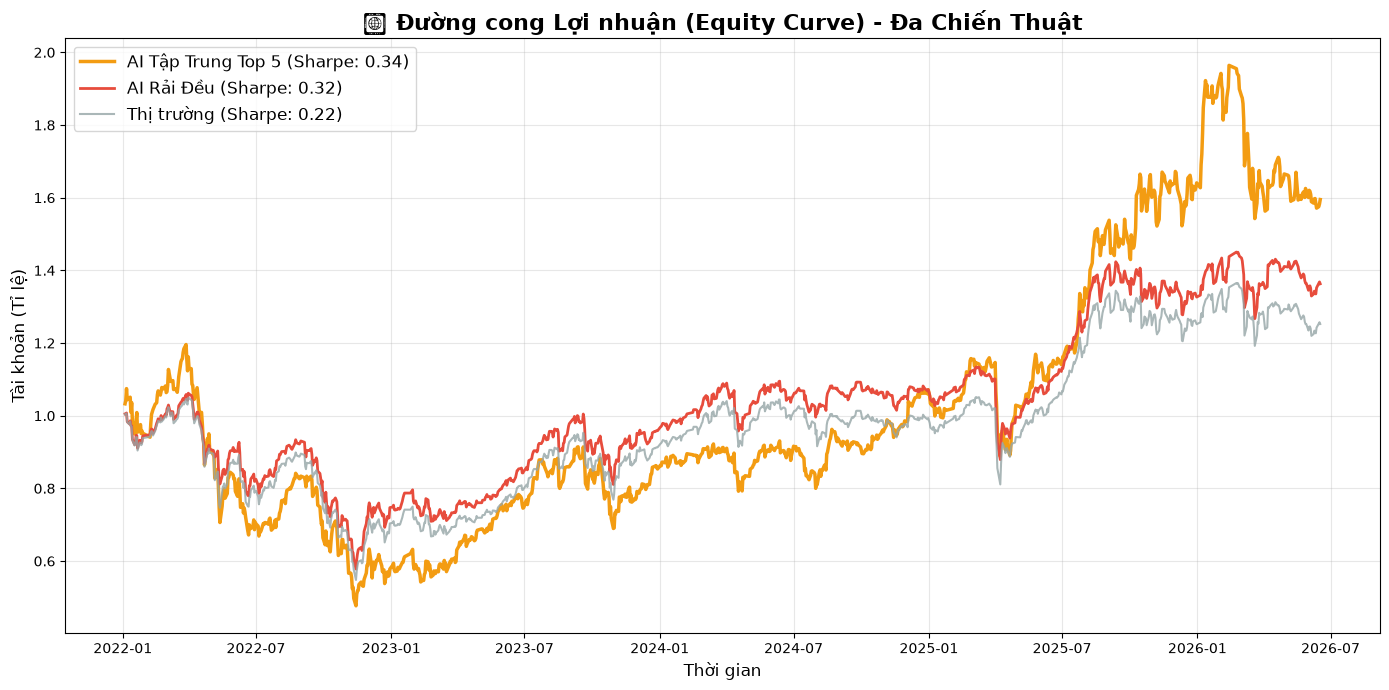

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

if 'df_backtest' in locals() and 'final_meta_pred_prob' in df_backtest.columns:
    df_bt = df_backtest.dropna(subset=['final_meta_pred_prob']).copy()
    N_stocks = df_bt['ticker'].nunique()
    
    # 1. Chiến lược 1: Mua rải đều (AI Equal Weight)
    # Lệnh mua ăn target_return_1d, lệnh đứng ngoài ăn 0%
    df_bt['signal_eq'] = (df_bt['final_meta_pred_prob'] > 0.4).astype(int)
    port_eq = df_bt.groupby('time').apply(
        lambda x: (x['target_return_1d'] * x['signal_eq']).sum() / N_stocks
    ).reset_index(name='ret_eq')
    
    # 2. Chiến lược 2: Tập trung Top 5 (AI Top 5 Conviction)
    # Mỗi ngày chọn ra 5 mã có xác suất cao nhất. Nếu xác suất > 0.5 thì mua (dành 20% vốn).
    def top_k_return(day_data, k=5):
        # Sắp xếp từ cao xuống thấp
        top_k = day_data.sort_values('final_meta_pred_prob', ascending=False).head(k)
        # Chỉ mua những mã > 0.5
        top_k_buy = top_k[top_k['final_meta_pred_prob'] > 0.4]
        if len(top_k_buy) == 0:
            return 0.0
        # Tính trung bình lợi nhuận của k mã (vốn chia đều k phần)
        return top_k_buy['target_return_1d'].sum() / k

    port_top5 = df_bt.groupby('time').apply(lambda x: top_k_return(x, k=5)).reset_index(name='ret_top5')
    
    # 3. Chiến lược Benchmark (Buy & Hold toàn bộ rổ)
    bench = df_bt.groupby('time').apply(
        lambda x: x['target_return_1d'].sum() / N_stocks
    ).reset_index(name='ret_bench')
    
    # Gộp kết quả
    df_perf = pd.merge(port_eq, port_top5, on='time')
    df_perf = pd.merge(df_perf, bench, on='time')
    
    df_perf['cum_eq'] = (1 + df_perf['ret_eq']).cumprod()
    df_perf['cum_top5'] = (1 + df_perf['ret_top5']).cumprod()
    df_perf['cum_bench'] = (1 + df_perf['ret_bench']).cumprod()
    
    # Hàm tính Metrics
    def calc_metrics(returns):
        cum = (1 + returns).cumprod()
        ann_ret = (cum.iloc[-1] ** (252 / len(returns))) - 1
        ann_vol = returns.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
        roll_max = cum.cummax()
        drawdown = cum / roll_max - 1
        max_dd = drawdown.min()
        win_rate = (returns > 0).mean()
        return ann_ret, ann_vol, sharpe, max_dd, win_rate

    metrics_eq = calc_metrics(df_perf['ret_eq'])
    metrics_top5 = calc_metrics(df_perf['ret_top5'])
    metrics_bench = calc_metrics(df_perf['ret_bench'])
    
    # Hiển thị Bảng Thống Kê
    perf_table = pd.DataFrame({
        'AI Tập Trung (Top 5)': [f"{metrics_top5[0]*100:.1f}%", f"{metrics_top5[1]*100:.1f}%", f"{metrics_top5[2]:.2f}", f"{metrics_top5[3]*100:.1f}%", f"{metrics_top5[4]*100:.1f}%"],
        'AI Rải Đều (Equal)': [f"{metrics_eq[0]*100:.1f}%", f"{metrics_eq[1]*100:.1f}%", f"{metrics_eq[2]:.2f}", f"{metrics_eq[3]*100:.1f}%", f"{metrics_eq[4]*100:.1f}%"],
        'Buy & Hold Benchmark': [f"{metrics_bench[0]*100:.1f}%", f"{metrics_bench[1]*100:.1f}%", f"{metrics_bench[2]:.2f}", f"{metrics_bench[3]*100:.1f}%", f"{metrics_bench[4]*100:.1f}%"]
    }, index=['Lợi nhuận năm (Ann. Ret)', 'Biến động năm (Ann. Vol)', 'Sharpe Ratio', 'Max Drawdown', 'Tỷ lệ ngày lãi (Win Rate)'])
    
    print("\n📊 BẢNG THỐNG KÊ HIỆU SUẤT GIAO DỊCH VỚI NHIỀU CHIẾN THUẬT (OOS)")
    display(perf_table)
    
    # Vẽ Equity Curve
    plt.figure(figsize=(14, 7))
    plt.plot(df_perf['time'], df_perf['cum_top5'], label=f"AI Tập Trung Top 5 (Sharpe: {metrics_top5[2]:.2f})", color='#f39c12', linewidth=2.5)
    plt.plot(df_perf['time'], df_perf['cum_eq'], label=f"AI Rải Đều (Sharpe: {metrics_eq[2]:.2f})", color='#e74c3c', linewidth=2)
    plt.plot(df_perf['time'], df_perf['cum_bench'], label=f"Thị trường (Sharpe: {metrics_bench[2]:.2f})", color='#95a5a6', linewidth=1.5, alpha=0.8)
    
    plt.title("📈 Đường cong Lợi nhuận (Equity Curve) - Đa Chiến Thuật", fontsize=16, fontweight='bold')
    plt.ylabel("Tài khoản (Tỉ lệ)", fontsize=12)
    plt.xlabel("Thời gian", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Vui lòng chạy Ô 9.1 (Walk-Forward Backtest) trước để có dữ liệu vẽ biểu đồ!")


## 10. Lưu Kết Quả & Trực Quan Hóa Tương Tác

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Lưu Market Regimes
if 'global_vars' in globals():
    global_vars.to_parquet(OUTPUT_DIR / 'market_regimes.parquet', index=False)
    global_vars.to_csv(OUTPUT_DIR / 'market_regimes.csv', index=False)
    print(f"Đã lưu: market_regimes (.parquet & .csv) {global_vars.shape}")

# 2. Lưu Sector Regimes
if 'df_sector_hmm' in globals():
    df_sector_hmm.to_parquet(OUTPUT_DIR / 'sector_regimes.parquet', index=False)
    df_sector_hmm.to_csv(OUTPUT_DIR / 'sector_regimes.csv', index=False)
    print(f"Đã lưu: sector_regimes (.parquet & .csv){df_sector_hmm.shape}")

# 3. Lưu Ticker Regimes (Master File)
master_ticker.to_parquet(OUTPUT_DIR / 'master_drl_ready_full.parquet', index=False)
master_ticker.to_csv(OUTPUT_DIR / 'master_drl_ready_full.csv', index=False)
print("Đã lưu: master_drl_ready_full (.parquet & .csv)")
print("\nHoàn tất quá trình lưu kết quả!")

import ipywidgets as widgets
from ipywidgets import interactive_output
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df_plot = master_ticker.copy()
if 'df_market_res' in globals() and 'market_regime_label' in df_market_res.columns:
    df_market_true = df_market_res[['time', 'market_regime_label']].rename(columns={'market_regime_label': 'true_market_regime'})
    df_plot = df_plot.merge(df_market_true, on='time', how='left')
else:
    df_plot['true_market_regime'] = df_plot.get('market_regime_label', df_plot.get('true_market_regime', 'Unknown'))

if 'market_regime_label' in df_plot.columns:
    df_plot.rename(columns={'market_regime_label': 'ticker_regime'}, inplace=True)

SEMANTIC_COLORS = {
    'Bull': '#2ecc71',
    'CalmBull': '#2ecc71',
    'Bear': '#e74c3c',
    'Crisis': '#e74c3c',
    'Euphoria': '#f39c12',
    'Sideways': '#95a5a6',
    'Tranquil': '#95a5a6',
    'State_0': '#2ecc71',
    'State_1': '#e74c3c',
    'State_2': '#95a5a6',
    'Tier0': '#e74c3c',
    'Tier1': '#95a5a6',
    'Tier2': '#2ecc71',
    'Unknown': '#e0e0e0'
}

def get_color(label):
    return SEMANTIC_COLORS.get(label, '#e0e0e0')

def plot_ticker_regimes(ticker, date_range):
    sub_df = df_plot[
        (df_plot['ticker'] == ticker) &
        (df_plot['time'] >= date_range[0]) &
        (df_plot['time'] <= date_range[1])
    ].copy().sort_values('time').reset_index(drop=True)
    
    if len(sub_df) == 0:
        print("Không có dữ liệu cho khoảng thời gian này.")
        return
        
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(16, 18), sharex=True, gridspec_kw={'height_ratios': [3, 3, 3, 1.5, 1.5]})
    times = sub_df['time']
    
    # 1. Market Regime vs VN-Index Close
    ax1.set_title(f"Mã: {ticker} | Ngành: {sub_df['industry'].iloc[0]}", fontsize=16, fontweight='bold')
    ax1.set_ylabel("VN-Index (Market)", fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    m_regimes = sub_df['true_market_regime']
    for i in range(1, len(sub_df)):
        if pd.notna(m_regimes.iloc[i]):
            c = get_color(m_regimes.iloc[i])
            ax1.plot([times.iloc[i-1], times.iloc[i]], [sub_df['vnindex_close'].iloc[i-1], sub_df['vnindex_close'].iloc[i]], color=c, linewidth=1.5)
        
    present_market = sorted(m_regimes.dropna().unique())
    legend_elements_1 = [Patch(facecolor=get_color(reg), edgecolor='none', label=f'Market: {reg}') for reg in present_market]
    ax1.legend(handles=legend_elements_1, loc='upper left', bbox_to_anchor=(1.01, 1))
    
    # 2. Sector Regime vs Ticker Close
    ax2.set_ylabel("Giá Ngành (Sector)", fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    s_regimes = sub_df['sector_regime_label']
    for i in range(1, len(sub_df)):
        if pd.notna(s_regimes.iloc[i]):
            c = get_color(s_regimes.iloc[i])
            ax2.plot([times.iloc[i-1], times.iloc[i]], [sub_df['close'].iloc[i-1], sub_df['close'].iloc[i]], color=c, linewidth=1.5)
        
    present_sector = sorted(s_regimes.dropna().unique())
    legend_elements_2 = [Patch(facecolor=get_color(reg), edgecolor='none', label=f'Sector: {reg}') for reg in present_sector]
    ax2.legend(handles=legend_elements_2, loc='upper left', bbox_to_anchor=(1.01, 1))

    # 3. Ticker Regime vs Ticker Close
    ax3.set_ylabel("Giá Mã (Ticker)", fontsize=12)
    ax3.grid(True, alpha=0.3)
    
    t_regimes = sub_df['ticker_regime_label']
    for i in range(1, len(sub_df)):
        if pd.notna(t_regimes.iloc[i]):
            c = get_color(t_regimes.iloc[i])
            ax3.plot([times.iloc[i-1], times.iloc[i]], [sub_df['close'].iloc[i-1], sub_df['close'].iloc[i]], color=c, linewidth=1.5)
        
    present_ticker = sorted(t_regimes.dropna().unique())
    legend_elements_3 = [Patch(facecolor=get_color(reg), edgecolor='none', label=f'Ticker: {reg}') for reg in present_ticker]
    ax3.legend(handles=legend_elements_3, loc='upper left', bbox_to_anchor=(1.01, 1))
    
    # 4. Volume
    ax4.bar(times, sub_df['volume'], color='grey', alpha=0.6, label="Volume")
    ax4.set_ylabel("Khối Lượng", fontsize=12)
    ax4.grid(True, alpha=0.3)
    
    # 5. Meta-Classifier Prob
    if 'final_meta_pred_prob' in sub_df.columns:
        ax5.plot(times, sub_df['final_meta_pred_prob'], color='blue', linewidth=1.5, label="Xác suất tăng T+1 (Meta)")
        ax5.axhline(0.5, color='red', linestyle='--', alpha=0.5)
        ax5.fill_between(times, sub_df['final_meta_pred_prob'], 0.5, where=(sub_df['final_meta_pred_prob'] > 0.5), color='#2ecc71', alpha=0.3)
        ax5.fill_between(times, sub_df['final_meta_pred_prob'], 0.5, where=(sub_df['final_meta_pred_prob'] <= 0.5), color='#e74c3c', alpha=0.3)
        ax5.set_ylabel("Xác suất Tăng", fontsize=12)
        ax5.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
        ax5.set_ylim(0, 1)
    
    ax5.set_xlabel("Thời Gian", fontsize=12)
    ax5.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

ticker_dropdown = widgets.Dropdown(options=sorted(df_plot['ticker'].unique()), value=df_plot['ticker'].iloc[0], description='Mã Ticker:')
dates = sorted(df_plot['time'].unique())
date_slider = widgets.SelectionRangeSlider(options=dates, index=(0, len(dates)-1), description='Khoảng Đo:', orientation='horizontal', layout={'width': '80%'})

ui = widgets.VBox([ticker_dropdown, date_slider])
out = interactive_output(plot_ticker_regimes, {'ticker': ticker_dropdown, 'date_range': date_slider})

display(ui, out)


Đã lưu: market_regimes (.parquet & .csv) (2382, 15)


Đã lưu: sector_regimes (.parquet & .csv)(21438, 19)


Đã lưu: master_drl_ready_full (.parquet & .csv)

Hoàn tất quá trình lưu kết quả!


Output()

## 11. Hiển Thị Biểu Đồ Tĩnh (Mã BID)

Đang vẽ biểu đồ tĩnh cho BID...


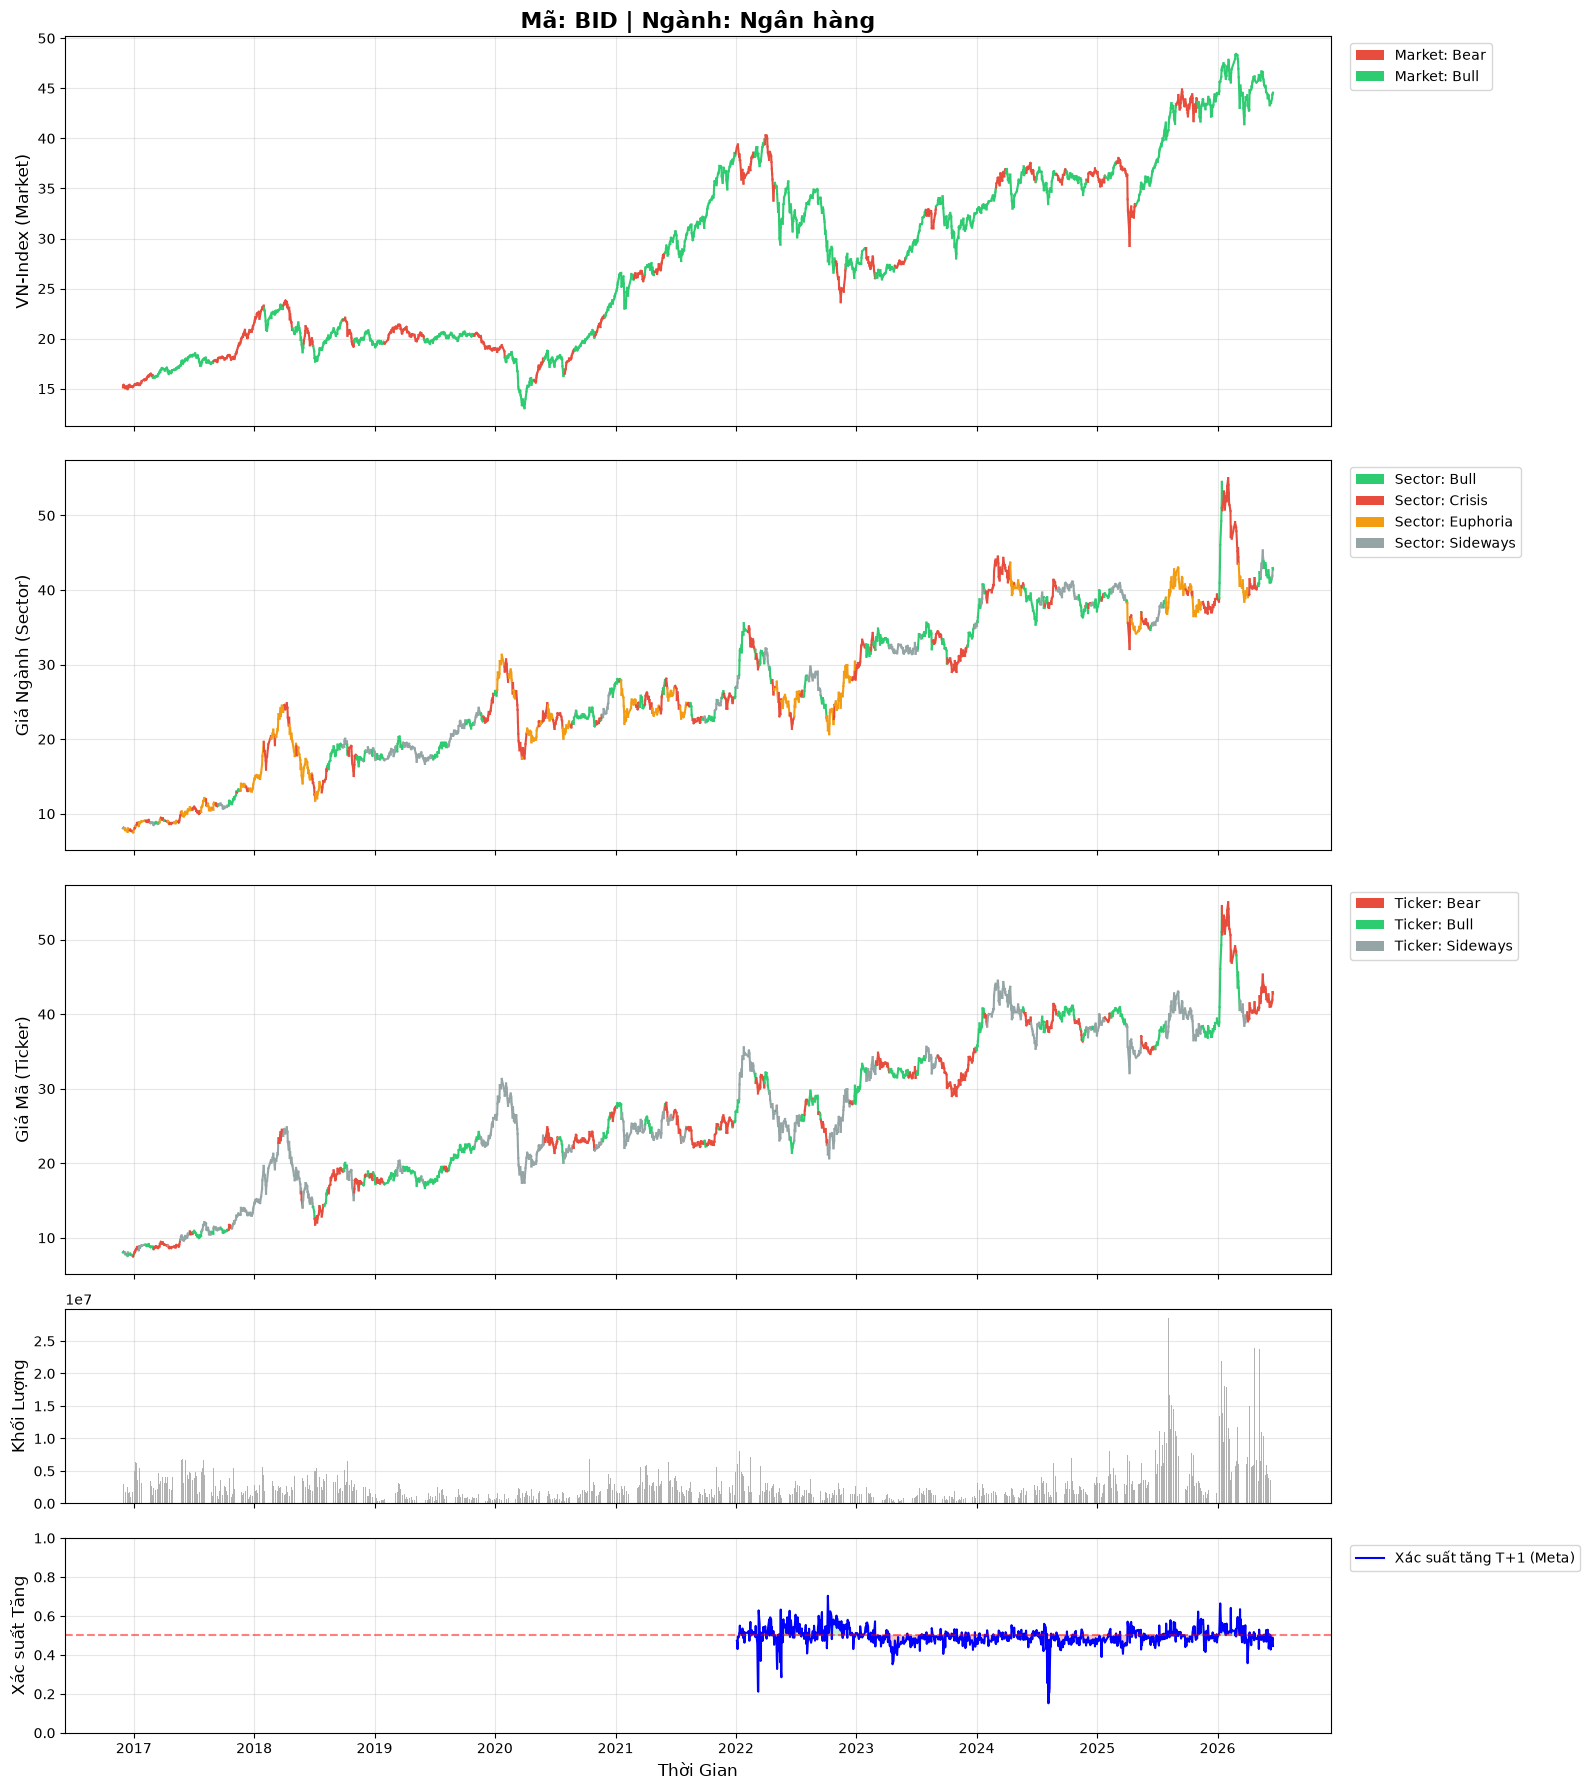

In [ ]:



ticker_to_plot = 'BID'
date_range = (df_plot['time'].min(), df_plot['time'].max())

print(f"Đang vẽ biểu đồ tĩnh cho {ticker_to_plot}...")
plot_ticker_regimes(ticker_to_plot, date_range)


ROC curve saved to C:\Users\ADMIN\.gemini\antigravity-cli\brain\12658c65-0507-48c7-a2d2-82b401dc1a40\roc_curve.png


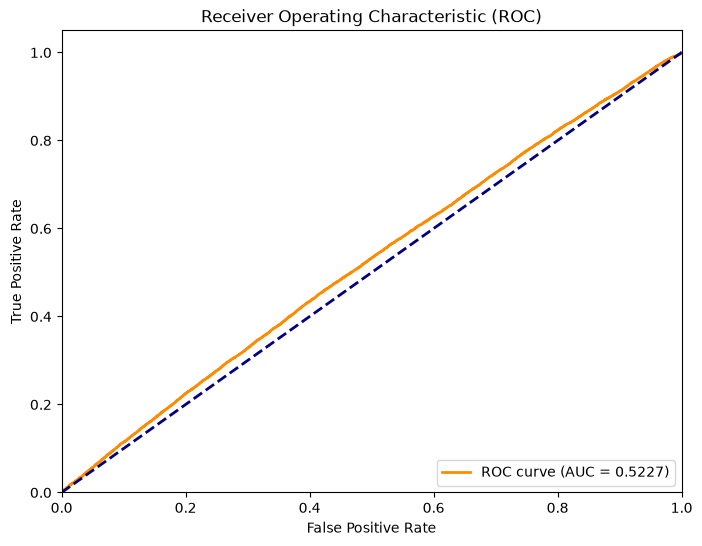

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_all, probs_all)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

artifact_dir = r'C:\Users\ADMIN\.gemini\antigravity-cli\brain\12658c65-0507-48c7-a2d2-82b401dc1a40'
if not os.path.exists(artifact_dir):
    os.makedirs(artifact_dir)
    
img_path = os.path.join(artifact_dir, 'roc_curve.png')
plt.savefig(img_path, dpi=150, bbox_inches='tight')
print(f"ROC curve saved to {img_path}")
plt.show()
